In [1]:
import os
import json
import ast

import pandas as pd
from collections import defaultdict
import numpy as np

In [14]:
# import matplotlib.pyplot as plt
# import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
from datasets import load_dataset, load_dataset_builder, get_dataset_split_names
from datasets import load_dataset, concatenate_datasets

/home/ryang/opt/miniforge3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from collections import Counter


In [5]:
from dotenv import load_dotenv

load_dotenv()


False

# Analyze logs (skip DeepSeek for now)

In [6]:
from inspect_ai.analysis import evals_df,  samples_df
# per eval, want to know its model and arguments (model? reasoning_effort? reasoning_enabled? )
# per eval, want to know overall table_match / cell_match mean 
# inside each eval, want to know table_match / cell_match per puzzle size 

## get usage & score per eval per size 

In [23]:
s_df = samples_df("../logs")

In [24]:
print(s_df.shape)
s_df.columns

(200, 22)


Index(['sample_id', 'eval_id', 'log', 'id', 'epoch', 'input', 'choices',
       'target', 'metadata_execution_result', 'metadata_failed',
       'metadata_puzzle', 'metadata_size', 'metadata_solution_inst',
       'score_max_cell_match', 'model_usage', 'total_tokens', 'total_time',
       'working_time', 'message_count', 'error', 'limit', 'retries'],
      dtype='str')

In [25]:
s_df['model_usage_parsed'] = s_df['model_usage'].apply(json.loads)
s_df['score_max_cell_match_parsed'] = s_df['score_max_cell_match'].apply(json.loads)

In [26]:
s_df['retry_exhausted'] = s_df["score_max_cell_match_parsed"].apply(
    lambda d: isinstance(d.get('table_match'), str)
)

def clean(d):
    if isinstance(d.get('table_match'), str):
        d['table_match'] = 0
    return d

s_df["score_max_cell_match_parsed"] = s_df["score_max_cell_match_parsed"].apply(clean)


In [30]:
s_df["score_max_cell_match_parsed"]

0      {'table_match': 1, 'cells_match_ratio': 1.0}
1      {'table_match': 1, 'cells_match_ratio': 1.0}
2      {'table_match': 1, 'cells_match_ratio': 1.0}
3      {'table_match': 1, 'cells_match_ratio': 1.0}
4      {'table_match': 1, 'cells_match_ratio': 1.0}
                           ...                     
195    {'table_match': 1, 'cells_match_ratio': 1.0}
196    {'table_match': 1, 'cells_match_ratio': 1.0}
197    {'table_match': 1, 'cells_match_ratio': 1.0}
198    {'table_match': 1, 'cells_match_ratio': 1.0}
199    {'table_match': 1, 'cells_match_ratio': 1.0}
Name: score_max_cell_match_parsed, Length: 200, dtype: object

In [31]:
def mean_dicts(series):
    """
    Average dicts across rows. Handles both:
      - Flat:  {"table_match": 1, "cells_match_ratio": 1.0}
      - Nested: {"model_name": {"input_tokens": 824, ...}}
    """
    accumulator = defaultdict(lambda: defaultdict(list))

    for d in series:
        for key, value in d.items():
            if isinstance(value, dict):
                # Nested case: key is a model name, value is a metrics dict
                for metric, v in value.items():
                    accumulator[key][metric].append(v)
            else:
                # Flat case: key is a metric name, value is a scalar
                accumulator['__flat__'][key].append(value)

    result = {}
    for outer_key, metrics in accumulator.items():
        averaged = {metric: np.mean(vals) for metric, vals in metrics.items()}
        if outer_key == '__flat__':
            # Unwrap the sentinel — restore flat structure
            result.update(averaged)
        else:
            result[outer_key] = averaged

    return result

In [32]:
s_df

,sample_id,eval_id,log,id,epoch,input,choices,target,metadata_execution_result,metadata_failed,...,total_tokens,total_time,working_time,message_count,error,limit,retries,model_usage_parsed,score_max_cell_match_parsed,retry_exhausted
0,SZCfqAP5ogQzKrXrLFRwSj,hWCMAADhQYQcfF9jGpTyGx,/home/ryang/Downloads/individual project/proje...,lgp-test-3x4-0,1,"user: # Example Puzzle There are 3 houses, nu...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...",<NA>,<NA>,...,2527,39.129,39.129,3,,<NA>,0,"{'openai/o3-2025-04-16': {'input_tokens': 815,...","{'table_match': 1, 'cells_match_ratio': 1.0}",False
1,Q5EkvEubdFb2qMz4wYxZx3,hWCMAADhQYQcfF9jGpTyGx,/home/ryang/Downloads/individual project/proje...,lgp-test-3x4-1,1,"user: # Example Puzzle There are 3 houses, nu...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...",<NA>,<NA>,...,2592,25.354,25.354,3,,<NA>,0,"{'openai/o3-2025-04-16': {'input_tokens': 823,...","{'table_match': 1, 'cells_match_ratio': 1.0}",False
2,XFpmm5xYt8a4h79yPY2CpK,hWCMAADhQYQcfF9jGpTyGx,/home/ryang/Downloads/individual project/proje...,lgp-test-3x4-2,1,"user: # Example Puzzle There are 3 houses, nu...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...",<NA>,<NA>,...,4170,48.088,48.088,3,,<NA>,0,"{'openai/o3-2025-04-16': {'input_tokens': 828,...","{'table_match': 1, 'cells_match_ratio': 1.0}",False
3,BRhxetcMLbu8YzxHBNc4CA,hWCMAADhQYQcfF9jGpTyGx,/home/ryang/Downloads/individual project/proje...,lgp-test-3x4-31,1,"user: # Example Puzzle There are 3 houses, nu...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...",<NA>,<NA>,...,2556,37.404,37.404,3,,<NA>,0,"{'openai/o3-2025-04-16': {'input_tokens': 834,...","{'table_match': 1, 'cells_match_ratio': 1.0}",False
4,DkM5LfmY6bSbt6ET5KWDC8,hWCMAADhQYQcfF9jGpTyGx,/home/ryang/Downloads/individual project/proje...,lgp-test-3x4-5,1,"user: # Example Puzzle There are 3 houses, nu...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...",<NA>,<NA>,...,2621,45.035,45.035,3,,<NA>,0,"{'openai/o3-2025-04-16': {'input_tokens': 824,...","{'table_match': 1, 'cells_match_ratio': 1.0}",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,e6aHGEEgeVKcjDh98QPHPN,cbqPLrujsTBuBkrbfsDBBy,/home/ryang/Downloads/individual project/proje...,lgp-test-6x6-1,1,"user: # Puzzle There are 6 houses, numbered 1 ...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...","[""name(2,bob)"", ""name(1,peter)"", ""name(6,arnol...",<NA>,...,36694,332.515,332.515,9,,<NA>,0,{'openai/o3-2025-04-16': {'input_tokens': 1044...,"{'table_match': 1, 'cells_match_ratio': 1.0}",False
196,Mzx7mDqpBCSBP23KwTqzQ2,cbqPLrujsTBuBkrbfsDBBy,/home/ryang/Downloads/individual project/proje...,lgp-test-6x6-12,1,"user: # Puzzle There are 6 houses, numbered 1 ...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...","[""person(1,arnold)"", ""person(2,bob)"", ""person(...",<NA>,...,18988,163.526,163.526,7,,<NA>,0,{'openai/o3-2025-04-16': {'input_tokens': 7311...,"{'table_match': 1, 'cells_match_ratio': 1.0}",False
197,hTedJ5wojxMcgSFXC5Rwib,cbqPLrujsTBuBkrbfsDBBy,/home/ryang/Downloads/individual project/proje...,lgp-test-6x6-22,1,"user: # Puzzle There are 6 houses, numbered 1 ...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...","[""name_at(5,peter)"", ""name_at(2,eric)"", ""name_...",<NA>,...,35477,499.155,499.155,5,,<NA>,0,{'openai/o3-2025-04-16': {'input_tokens': 3516...,"{'table_match': 1, 'cells_match_ratio': 1.0}",False
198,NYByRxU84KuFZanbG2t9NB,cbqPLrujsTBuBkrbfsDBBy,/home/ryang/Downloads/individual project/proje...,lgp-test-6x6-26,1,"user: # Puzzle There are 6 houses, numbered 1 ...",<NA>,"{'reasoning': '___', 'solution': '{""House 1"":{...","[""at(2,phone,oneplus_9)"", ""at(1,person,alice)""...",<NA>,...,25344,294.904,294.904,5,,<NA>,0,{'openai/o3-2025-04-16': {'input_tokens': 3735...,"{'table_match': 1, 'cells_match_ratio': 1.0}",False


In [49]:
metric_by_size = s_df.groupby(['eval_id',  'metadata_size'], observed=True).agg(
      model_usage_mean=('model_usage_parsed', mean_dicts),
      max_cell_match_mean=('score_max_cell_match_parsed', mean_dicts),
  ).unstack('metadata_size').reset_index()   

metric_by_size.head()

eval_id  \
metadata_size                           
0              4zuwKAQQDNoyQ5HzRU3YLj   
1              Aif4kxPtQ6GAo3QJ3sd9f7   
2              BgpwXDUgWHLZBzo2aPTVU5   
3              CNz7Sr9Ara5v8UYgetE2d5   
4              FBWpmAcbAN9Zdw5ZDmsHf7   

                                                model_usage_mean  \
metadata_size                                                3*4   
0              {'openai/gpt-5.4': {'input_tokens': 1713.4, 'o...   
1              {'openai/gpt-5.4': {'input_tokens': 1647.8, 'o...   
2              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
3              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
4              {'openai/gpt-5.4': {'input_tokens': 783.8, 'ou...   

                                                                  \
metadata_size                                                4*5   
0              {'openai/gpt-5.4': {'input_tokens': 1032.8, 'o...   
1              {'openai/gpt-5.4': {'input_tokens': 2353.6, 'o...   
2              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
3              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
4              {'openai/gpt-5.4': {'input_tokens': 929.6, 'ou...   

                                                                  \
metadata_size                                                5*6   
0              {'openai/gpt-5.4': {'input_tokens': 1341.2, 'o...   
1              {'openai/gpt-5.4': {'input_tokens': 3082.2, 'o...   
2              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
3              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
4              {'openai/gpt-5.4': {'input_tokens': 1077.4, 'o...   

                                                                  \
metadata_size                                                6*6   
0              {'openai/gpt-5.4': {'input_tokens': 2072.2, 'o...   
1              {'openai/gpt-5.4': {'input_tokens': 3597.6, 'o...   
2              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
3              {'openai/gpt-4.1-2025-04-14': {'input_tokens':...   
4              {'openai/gpt-5.4': {'input_tokens': 988.2, 'ou...   

                                             max_cell_match_mean  \
metadata_size                                                3*4   
0                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
1                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
2              {'table_match': 0.4, 'cells_match_ratio': 0.63...   
3                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
4              {'table_match': 0.8, 'cells_match_ratio': 0.93...   

                                                                  \
metadata_size                                                4*5   
0                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
1                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
2                {'table_match': 0.0, 'cells_match_ratio': 0.29}   
3              {'table_match': 0.4, 'cells_match_ratio': 0.59...   
4                {'table_match': 0.2, 'cells_match_ratio': 0.67}   

                                                                  \
metadata_size                                                5*6   
0                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
1                 {'table_match': 1.0, 'cells_match_ratio': 1.0}   
2              {'table_match': 0.0, 'cells_match_ratio': 0.31...   
3              {'table_match': 0.2, 'cells_match_ratio': 0.39...   
4              {'table_match': 0.0, 'cells_match_ratio': 0.32...   

                                                                  
metadata_size                                                6*6  
0              {'table_match': 0.8, 'cells_match_ratio': 0.99...  
1                 {'table_match': 1.0, 'cells_match_ratio': 1.0}  
2              {'table_match': 0.0, 'cells_match_ratio': 0.26...  
3                 {'table_match': 0.0, 'cells_match_ratio': 0.0}  
4

In [50]:
metric_by_size.shape

(10, 9)

In [51]:
metric_by_size.columns

MultiIndex([(            'eval_id',    ''),
            (   'model_usage_mean', '3*4'),
            (   'model_usage_mean', '4*5'),
            (   'model_usage_mean', '5*6'),
            (   'model_usage_mean', '6*6'),
            ('max_cell_match_mean', '3*4'),
            ('max_cell_match_mean', '4*5'),
            ('max_cell_match_mean', '5*6'),
            ('max_cell_match_mean', '6*6')],
           names=[None, 'metadata_size'])

In [52]:
def flatten_columns(df):
    def rename_col(top, sub):
        if sub == '':
            return top
        elif top == 'model_usage_mean':
            return f'usage_mean_{sub}'
        elif top == 'max_cell_match_mean':
            return f'score_mean_{sub}'
        else:
            # Generic fallback: just join non-empty parts
            return f'{top}_{sub}' if sub else top

    df.columns = [rename_col(top, sub) for top, sub in df.columns]
    return df

In [53]:
m_by_size_flat = flatten_columns(metric_by_size)
m_by_size_flat

,eval_id,usage_mean_3*4,usage_mean_4*5,usage_mean_5*6,usage_mean_6*6,score_mean_3*4,score_mean_4*5,score_mean_5*6,score_mean_6*6
0,4zuwKAQQDNoyQ5HzRU3YLj,"{'openai/gpt-5.4': {'input_tokens': 1713.4, 'o...","{'openai/gpt-5.4': {'input_tokens': 1032.8, 'o...","{'openai/gpt-5.4': {'input_tokens': 1341.2, 'o...","{'openai/gpt-5.4': {'input_tokens': 2072.2, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 0.8, 'cells_match_ratio': 0.99..."
1,Aif4kxPtQ6GAo3QJ3sd9f7,"{'openai/gpt-5.4': {'input_tokens': 1647.8, 'o...","{'openai/gpt-5.4': {'input_tokens': 2353.6, 'o...","{'openai/gpt-5.4': {'input_tokens': 3082.2, 'o...","{'openai/gpt-5.4': {'input_tokens': 3597.6, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
2,BgpwXDUgWHLZBzo2aPTVU5,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,"{'table_match': 0.4, 'cells_match_ratio': 0.63...","{'table_match': 0.0, 'cells_match_ratio': 0.29}","{'table_match': 0.0, 'cells_match_ratio': 0.31...","{'table_match': 0.0, 'cells_match_ratio': 0.26..."
3,CNz7Sr9Ara5v8UYgetE2d5,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,"{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 0.4, 'cells_match_ratio': 0.59...","{'table_match': 0.2, 'cells_match_ratio': 0.39...","{'table_match': 0.0, 'cells_match_ratio': 0.0}"
4,FBWpmAcbAN9Zdw5ZDmsHf7,"{'openai/gpt-5.4': {'input_tokens': 783.8, 'ou...","{'openai/gpt-5.4': {'input_tokens': 929.6, 'ou...","{'openai/gpt-5.4': {'input_tokens': 1077.4, 'o...","{'openai/gpt-5.4': {'input_tokens': 988.2, 'ou...","{'table_match': 0.8, 'cells_match_ratio': 0.93...","{'table_match': 0.2, 'cells_match_ratio': 0.67}","{'table_match': 0.0, 'cells_match_ratio': 0.32...","{'table_match': 0.0, 'cells_match_ratio': 0.47..."
5,RGQsUfwUmoamWUUijBRht7,{'openai/o3-2025-04-16': {'input_tokens': 824....,{'openai/o3-2025-04-16': {'input_tokens': 970....,{'openai/o3-2025-04-16': {'input_tokens': 1118...,{'openai/o3-2025-04-16': {'input_tokens': 1234...,"{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 0.2, 'cells_match_ratio': 0.2}"
6,YRopaGiK5ojxkPxFc9JnX2,{'openai/o3-2025-04-16': {'input_tokens': 2464...,{'openai/o3-2025-04-16': {'input_tokens': 3803...,{'openai/o3-2025-04-16': {'input_tokens': 4587...,{'openai/o3-2025-04-16': {'input_tokens': 4260...,"{'table_match': 0.8, 'cells_match_ratio': 0.8}","{'table_match': 0.6, 'cells_match_ratio': 0.93}","{'table_match': 0.6, 'cells_match_ratio': 0.78...","{'table_match': 0.8, 'cells_match_ratio': 0.99..."
7,cbqPLrujsTBuBkrbfsDBBy,{'openai/o3-2025-04-16': {'input_tokens': 1661...,{'openai/o3-2025-04-16': {'input_tokens': 2363...,{'openai/o3-2025-04-16': {'input_tokens': 4320...,{'openai/o3-2025-04-16': {'input_tokens': 5716...,"{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
8,hLjeRuVBzEhmbmoZWiMYGL,"{'openai/gpt-5.4': {'input_tokens': 824.8, 'ou...","{'openai/gpt-5.4': {'input_tokens': 970.6, 'ou...","{'openai/gpt-5.4': {'input_tokens': 1118.4, 'o...","{'openai/gpt-5.4': {'input_tokens': 1234.0, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
9,hWCMAADhQYQc

In [54]:
def test(df): 
    eval_col = df[['eval_id']]
    
    # Melt the metric columns
    metrics = ['usage_mean', 'score_mean']
    size_labels = ['3*4', '4*5', '5*6', '6*6']
    
    melted_parts = []
    for size in size_labels:
        part = df[[f'{m}_{size}' for m in metrics]].copy()
        part.columns = metrics
        part['size'] = size
        melted_parts.append(pd.concat([eval_col, part], axis=1))
    
    result = pd.concat(melted_parts, ignore_index=True)
    # Reorder columns
    result = result[['eval_id', 'size', 'usage_mean', 'score_mean']]
    result = result.sort_values(by=['eval_id', 'size']) 
    result.reset_index(inplace=True, drop=True)
    return result 

In [55]:
m_clean = test(m_by_size_flat)

In [56]:
m_clean

,eval_id,size,usage_mean,score_mean
0,4zuwKAQQDNoyQ5HzRU3YLj,3*4,"{'openai/gpt-5.4': {'input_tokens': 1713.4, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
1,4zuwKAQQDNoyQ5HzRU3YLj,4*5,"{'openai/gpt-5.4': {'input_tokens': 1032.8, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
2,4zuwKAQQDNoyQ5HzRU3YLj,5*6,"{'openai/gpt-5.4': {'input_tokens': 1341.2, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
3,4zuwKAQQDNoyQ5HzRU3YLj,6*6,"{'openai/gpt-5.4': {'input_tokens': 2072.2, 'o...","{'table_match': 0.8, 'cells_match_ratio': 0.99..."
4,Aif4kxPtQ6GAo3QJ3sd9f7,3*4,"{'openai/gpt-5.4': {'input_tokens': 1647.8, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
5,Aif4kxPtQ6GAo3QJ3sd9f7,4*5,"{'openai/gpt-5.4': {'input_tokens': 2353.6, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
6,Aif4kxPtQ6GAo3QJ3sd9f7,5*6,"{'openai/gpt-5.4': {'input_tokens': 3082.2, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
7,Aif4kxPtQ6GAo3QJ3sd9f7,6*6,"{'openai/gpt-5.4': {'input_tokens': 3597.6, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}"
8,BgpwXDUgWHLZBzo2aPTVU5,3*4,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,"{'table_match': 0.4, 'cells_match_ratio': 0.63..."
9,BgpwXDUgWHLZBzo2aPTVU5,4*5,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,"{'table_match': 0.0, 'cells_match_ratio': 0.29}"


In [57]:
m_clean['table_match'] = m_clean['score_mean'].apply(lambda d: d['table_match'])
m_clean['cell_match'] = m_clean['score_mean'].apply(lambda d: d['cells_match_ratio'])

In [58]:
m_clean

,eval_id,size,usage_mean,score_mean,table_match,cell_match
0,4zuwKAQQDNoyQ5HzRU3YLj,3*4,"{'openai/gpt-5.4': {'input_tokens': 1713.4, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
1,4zuwKAQQDNoyQ5HzRU3YLj,4*5,"{'openai/gpt-5.4': {'input_tokens': 1032.8, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
2,4zuwKAQQDNoyQ5HzRU3YLj,5*6,"{'openai/gpt-5.4': {'input_tokens': 1341.2, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
3,4zuwKAQQDNoyQ5HzRU3YLj,6*6,"{'openai/gpt-5.4': {'input_tokens': 2072.2, 'o...","{'table_match': 0.8, 'cells_match_ratio': 0.99...",0.8,0.994444
4,Aif4kxPtQ6GAo3QJ3sd9f7,3*4,"{'openai/gpt-5.4': {'input_tokens': 1647.8, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
5,Aif4kxPtQ6GAo3QJ3sd9f7,4*5,"{'openai/gpt-5.4': {'input_tokens': 2353.6, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
6,Aif4kxPtQ6GAo3QJ3sd9f7,5*6,"{'openai/gpt-5.4': {'input_tokens': 3082.2, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
7,Aif4kxPtQ6GAo3QJ3sd9f7,6*6,"{'openai/gpt-5.4': {'input_tokens': 3597.6, 'o...","{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
8,BgpwXDUgWHLZBzo2aPTVU5,3*4,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,"{'table_match': 0.4, 'cells_match_ratio': 0.63...",0.4,0.633333
9,BgpwXDUgWHLZBzo2aPTVU5,4*5,{'openai/gpt-4.1-2025-04-14': {'input_tokens':...,"{'table_match': 0.0, 'cells_match_ratio': 0.29}",0.0,0.290000


## get task, model, gen_config per eval

In [59]:
df = evals_df("../logs")  
print(df.columns)
for col in df.columns:
    print(col) 
    print(df[col].iloc[0])
    print('\n')

Index(['eval_id', 'eval_set_id', 'run_id', 'task_id', 'log', 'created', 'tags',
       'git_origin', 'git_commit', 'packages', 'metadata', 'task_name',
       'task_display_name', 'task_version', 'task_file', 'task_attribs',
       'solver', 'solver_args', 'sandbox_type', 'sandbox_config', 'model',
       'model_base_url', 'model_args', 'model_generate_config', 'model_roles',
       'dataset_name', 'dataset_location', 'dataset_samples',
       'dataset_sample_ids', 'dataset_shuffled', 'epochs', 'epochs_reducer',
       'approval', 'message_limit', 'token_limit', 'time_limit',
       'working_limit', 'status', 'error_message', 'error_traceback',
       'total_samples', 'completed_samples', 'score_headline_name',
       'score_headline_metric', 'score_headline_value',
       'score_headline_stderr', 'score_cells_match_ratio_mean',
       'score_cells_match_ratio_stderr', 'score_table_match_mean',
       'score_table_match_stderr'],
      dtype='str')
eval_id
hWCMAADhQYQcfF9jGpTyGx


eval

In [60]:
df = df[['eval_id', 'task_name','model', 'model_generate_config', 'score_cells_match_ratio_mean', 'score_table_match_mean']]
df

,eval_id,task_name,model,model_generate_config,score_cells_match_ratio_mean,score_table_match_mean
0,hWCMAADhQYQcfF9jGpTyGx,naive_cot,openai/o3-2025-04-16,"{""reasoning_effort"": ""high""}",0.929167,0.9
1,FBWpmAcbAN9Zdw5ZDmsHf7,naive_cot,openai/gpt-5.4,{},0.601944,0.25
2,Aif4kxPtQ6GAo3QJ3sd9f7,nesy,openai/gpt-5.4,"{""reasoning_effort"": ""xhigh""}",1.0,1.0
3,CNz7Sr9Ara5v8UYgetE2d5,nesy,openai/gpt-4.1-2025-04-14,{},0.495833,0.4
4,RGQsUfwUmoamWUUijBRht7,naive_cot,openai/o3-2025-04-16,"{""reasoning_effort"": ""low""}",0.8,0.8
5,hLjeRuVBzEhmbmoZWiMYGL,naive_cot,openai/gpt-5.4,"{""reasoning_effort"": ""xhigh""}",1.0,1.0
6,BgpwXDUgWHLZBzo2aPTVU5,naive_cot,openai/gpt-4.1-2025-04-14,{},0.3775,0.1
7,YRopaGiK5ojxkPxFc9JnX2,nesy,openai/o3-2025-04-16,"{""reasoning_effort"": ""low""}",0.877778,0.7
8,4zuwKAQQDNoyQ5HzRU3YLj,nesy,openai/gpt-5.4,{},0.998611,0.95
9,cbqPLrujsTBuBkrbfsDBBy,nesy,openai/o3-2025-04-16,"{""reasoning_effort"": ""high""}",1.0,1.0


In [61]:
mask = (df['model'] == 'openai/gpt-5.4') & (df['model_generate_config'] == '{}')
# default is none when not specified
df.loc[mask, 'model_generate_config'] = '{"reasoning_effort": "none"}'

## get full df

In [62]:
full = pd.merge(df, m_clean, on='eval_id', how='inner')
full.head()

# 3 categorical var: model, size, task 
# 2 numerical var: table_match, cell_match 

,eval_id,task_name,model,model_generate_config,score_cells_match_ratio_mean,score_table_match_mean,size,usage_mean,score_mean,table_match,cell_match
0,hWCMAADhQYQcfF9jGpTyGx,naive_cot,openai/o3-2025-04-16,"{""reasoning_effort"": ""high""}",0.929167,0.9,3*4,{'openai/o3-2025-04-16': {'input_tokens': 824....,"{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
1,hWCMAADhQYQcfF9jGpTyGx,naive_cot,openai/o3-2025-04-16,"{""reasoning_effort"": ""high""}",0.929167,0.9,4*5,{'openai/o3-2025-04-16': {'input_tokens': 970....,"{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
2,hWCMAADhQYQcfF9jGpTyGx,naive_cot,openai/o3-2025-04-16,"{""reasoning_effort"": ""high""}",0.929167,0.9,5*6,{'openai/o3-2025-04-16': {'input_tokens': 3607...,"{'table_match': 1.0, 'cells_match_ratio': 1.0}",1.0,1.000000
3,hWCMAADhQYQcfF9jGpTyGx,naive_cot,openai/o3-2025-04-16,"{""reasoning_effort"": ""high""}",0.929167,0.9,6*6,{'openai/o3-2025-04-16': {'input_tokens': 1361...,"{'table_match': 0.6, 'cells_match_ratio': 0.71...",0.6,0.716667
4,FBWpmAcbAN9Zdw5ZDmsHf7,naive_cot,openai/gpt-5.4,"{""reasoning_effort"": ""none""}",0.601944,0.25,3*4,"{'openai/gpt-5.4': {'input_tokens': 783.8, 'ou...","{'table_match': 0.8, 'cells_match_ratio': 0.93...",0.8,0.933333


In [63]:
conditions = [
    full['model'].str.contains('o3') & full['model_generate_config'].str.contains('high'),
    full['model'].str.contains('o3') & full['model_generate_config'].str.contains('low'),
    full['model'].str.contains('gpt-5.4') & full['model_generate_config'].str.contains('none'),
    full['model'].str.contains('gpt-5.4') & full['model_generate_config'].str.contains('xhigh'),
    full['model'].str.contains('gpt-4.1'),
]
choices = ['o3-high', 'o3-low', 'gpt-5.4-none', 'gpt-5.4-xhigh', 'gpt-4.1']

full['model_alias'] = np.select(conditions, choices, default='unknown')

In [64]:
ready = full[['eval_id', 'model_alias', 'task_name', 'score_table_match_mean', 'score_cells_match_ratio_mean', 'size', 'table_match', 'cell_match']]
ready.rename(columns={
    'model_alias': 'model',
    'score_table_match_mean': 'overall_table_match', 
    'score_cells_match_ratio_mean': 'overall_cell_match'}, 
             inplace=True)
ready.head()

,eval_id,model,task_name,overall_table_match,overall_cell_match,size,table_match,cell_match
0,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,3*4,1.0,1.000000
1,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,4*5,1.0,1.000000
2,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,5*6,1.0,1.000000
3,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,6*6,0.6,0.716667
4,FBWpmAcbAN9Zdw5ZDmsHf7,gpt-5.4-none,naive_cot,0.25,0.601944,3*4,0.8,0.933333


In [65]:
ready

,eval_id,model,task_name,overall_table_match,overall_cell_match,size,table_match,cell_match
0,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,3*4,1.0,1.000000
1,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,4*5,1.0,1.000000
2,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,5*6,1.0,1.000000
3,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.9,0.929167,6*6,0.6,0.716667
4,FBWpmAcbAN9Zdw5ZDmsHf7,gpt-5.4-none,naive_cot,0.25,0.601944,3*4,0.8,0.933333
5,FBWpmAcbAN9Zdw5ZDmsHf7,gpt-5.4-none,naive_cot,0.25,0.601944,4*5,0.2,0.670000
6,FBWpmAcbAN9Zdw5ZDmsHf7,gpt-5.4-none,naive_cot,0.25,0.601944,5*6,0.0,0.326667
7,FBWpmAcbAN9Zdw5ZDmsHf7,gpt-5.4-none,naive_cot,0.25,0.601944,6*6,0.0,0.477778
8,Aif4kxPtQ6GAo3QJ3sd9f7,gpt-5.4-xhigh,nesy,1.0,1.0,3*4,1.0,1.000000
9,Aif4kxPtQ6GAo3QJ3sd9f7,gpt-5.4-xhigh,nesy,1.0,1.0,4*5,1.0,1.000000


In [66]:
ready.to_csv('ready.csv', index=False)


## plot

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [5]:
ready = pd.read_csv('ready.csv')
ready.head()

,eval_id,model,task_name,overall_table_match,overall_cell_match,size,table_match,cell_match
0,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.90,0.929167,3*4,1.0,1.000000
1,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.90,0.929167,4*5,1.0,1.000000
2,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.90,0.929167,5*6,1.0,1.000000
3,hWCMAADhQYQcfF9jGpTyGx,o3-high,naive_cot,0.90,0.929167,6*6,0.6,0.716667
4,FBWpmAcbAN9Zdw5ZDmsHf7,gpt-5.4-none,naive_cot,0.25,0.601944,3*4,0.8,0.933333


In [8]:
def add_jitter(series, factor=0.25):
    """Adds small, controlled, random horizontal noise (jitter) to a numerical series."""
    return series + np.random.uniform(-factor, factor, size=len(series))


def plot1(df, metric, primary_x, secondary_x, tertiary_x=None, agg=False,
          color_mapping=None, marker_mapping=None, save_name=None):
    """
    agg:        apart from primary_x and secondary_x, there is another categorical column
                agg indicates whether to aggregate across that third categorical column
    tertiary_x: optional column to encode as marker shape
    color_mapping: optional dict mapping secondary_x values → colors
    marker_mapping: optional dict mapping tertiary_x values → marker strings
    save_name:  optional filepath to save the figure
    """

    df_focus = df.copy()

    if agg:
        group_cols = [primary_x, secondary_x] + ([tertiary_x] if tertiary_x else [])
        df_focus = df_focus.groupby(group_cols)[metric].agg('mean').reset_index()

    # --- X-axis numerical mapping for jitter ---
    order = sorted(df_focus[primary_x].unique())
    x_map = {val: i for i, val in enumerate(order)}
    df_plot = df_focus.copy()
    df_plot['x_position'] = df_plot[primary_x].map(x_map)
    df_plot['x_jittered'] = add_jitter(df_plot['x_position'], factor=0.3)

    # --- Plot ---
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # Boxplot on categorical axis
    sns.boxplot(
        data=df_focus, x=primary_x, y=metric,
        color='whitesmoke', order=order,
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black'),
        medianprops=dict(color='gray'),
        capprops=dict(color='black'),
        ax=ax
    )

    # Scatterplot with jitter, hue, and optional marker style
    scatter_kwargs = dict(
        data=df_plot,
        x='x_jittered',
        y=metric,
        hue=secondary_x,
        alpha=0.8,
        s=150,
        zorder=10,
        ax=ax
    )
    if color_mapping:
        scatter_kwargs['palette'] = color_mapping
    if tertiary_x:
        scatter_kwargs['style'] = tertiary_x
    if marker_mapping and tertiary_x:
        scatter_kwargs['markers'] = marker_mapping

    sns.scatterplot(**scatter_kwargs)

    # --- X-axis labels ---
    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(list(x_map.keys()), rotation=45, ha='right')
    ax.set_xlabel(primary_x)
    ax.set_ylabel(metric)

    # --- Aesthetics ---
    sns.set_theme(style="whitegrid")
    ax.grid(True, axis='y', linestyle='--', alpha=0.7, color='lightgray')
    ax.grid(False, axis='x')
    ax.set_facecolor('#F8F8F8')

    title_parts = [f"{metric} by {primary_x}"]
    title_parts.append(f"color={secondary_x}")
    if tertiary_x:
        title_parts.append(f"shape={tertiary_x}")
    if agg:
        title_parts.append("(aggregated)")
    plt.title(" | ".join(title_parts), fontsize=14, pad=15)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

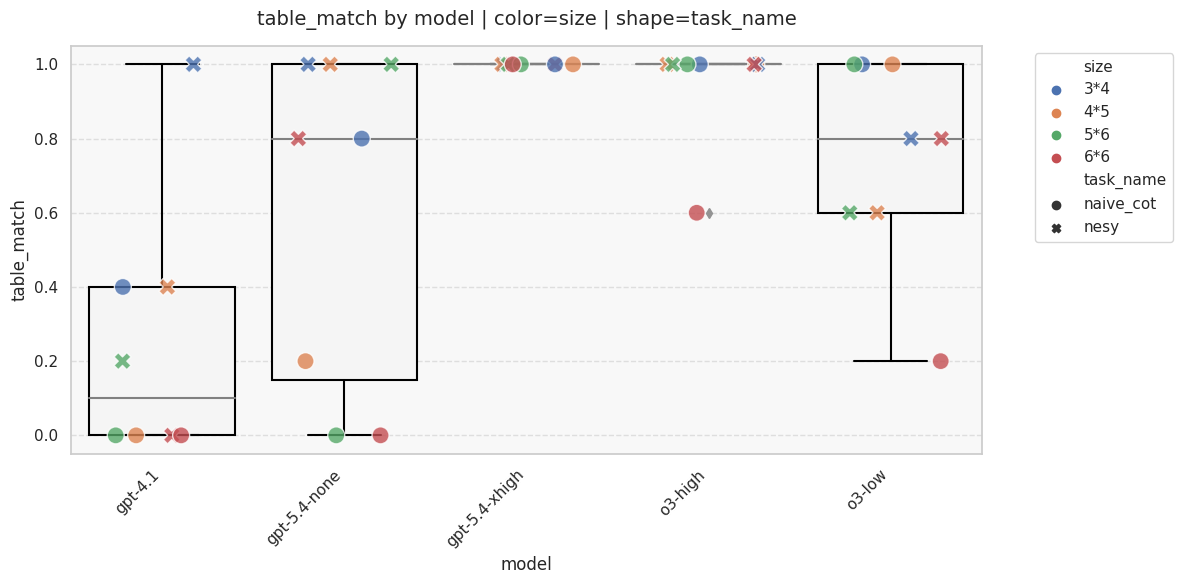

In [11]:
plot1(ready, "table_match", "model", "size", "task_name", save_name="overall_table_match.pdf")

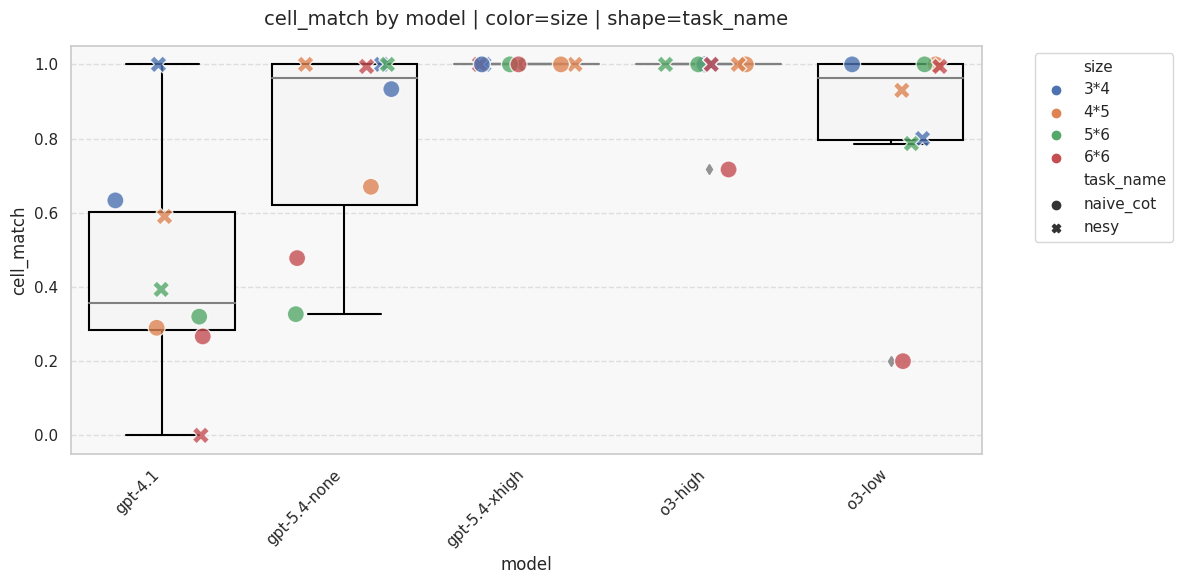

In [12]:
plot1(ready, "cell_match", "model", "size", "task_name", save_name="overall_cell_match.pdf")

## the latex table

In [86]:
overall_table_match = ready.pivot_table(index=['model'], columns=['task_name'], values='overall_table_match')
overall_table_match.columns = pd.MultiIndex.from_product([['overall'], overall_table_match.columns])

table_match_per_size = ready.pivot_table(index=['model'], columns=['size', 'task_name'], values='table_match')

table_match_report = pd.concat([table_match_per_size, overall_table_match], axis=1)
table_match_report

3*4            4*5            5*6            6*6       \
task_name     naive_cot nesy naive_cot nesy naive_cot nesy naive_cot nesy   
model                                                                       
gpt-4.1             0.4  1.0       0.0  0.4       0.0  0.2       0.0  0.0   
gpt-5.4-none        0.8  1.0       0.2  1.0       0.0  1.0       0.0  0.8   
gpt-5.4-xhigh       1.0  1.0       1.0  1.0       1.0  1.0       1.0  1.0   
o3-high             1.0  1.0       1.0  1.0       1.0  1.0       0.6  1.0   
o3-low              1.0  0.8       1.0  0.6       1.0  0.6       0.2  0.8   

                overall        
task_name     naive_cot  nesy  
model                          
gpt-4.1             0.1   0.4  
gpt-5.4-none       0.25  0.95  
gpt-5.4-xhigh       1.0   1.0  
o3-high             0.9   1.0  
o3-low              0.8   0.7

In [87]:
print(table_match_report.to_string())

                    3*4            4*5            5*6            6*6        overall      
task_name     naive_cot nesy naive_cot nesy naive_cot nesy naive_cot nesy naive_cot  nesy
model                                                                                    
gpt-4.1             0.4  1.0       0.0  0.4       0.0  0.2       0.0  0.0       0.1   0.4
gpt-5.4-none        0.8  1.0       0.2  1.0       0.0  1.0       0.0  0.8      0.25  0.95
gpt-5.4-xhigh       1.0  1.0       1.0  1.0       1.0  1.0       1.0  1.0       1.0   1.0
o3-high             1.0  1.0       1.0  1.0       1.0  1.0       0.6  1.0       0.9   1.0
o3-low              1.0  0.8       1.0  0.6       1.0  0.6       0.2  0.8       0.8   0.7


In [16]:
overall_cell_match = ready.pivot_table(index=['model'], 
                                       columns=['task_name'], 
                                       values='overall_cell_match').round(2)
overall_cell_match.columns = pd.MultiIndex.from_product([['overall'], overall_cell_match.columns])

cell_match_per_size = ready.pivot_table(index=['model'], 
                                        columns=['size', 'task_name'], 
                                        values='cell_match').round(2)

cell_match_report = pd.concat([cell_match_per_size, overall_cell_match], axis=1)
cell_match_report

3*4            4*5             5*6             6*6         
task_name     naive_cot nesy naive_cot  nesy naive_cot  nesy naive_cot  nesy   
model                                                                          
gpt-4.1            0.63  1.0      0.29  0.59      0.32  0.39      0.27  0.00  \
gpt-5.4-none       0.93  1.0      0.67  1.00      0.33  1.00      0.48  0.99   
gpt-5.4-xhigh      1.00  1.0      1.00  1.00      1.00  1.00      1.00  1.00   
o3-high            1.00  1.0      1.00  1.00      1.00  1.00      0.72  1.00   
o3-low             1.00  0.8      1.00  0.93      1.00  0.79      0.20  0.99   

                overall        
task_name     naive_cot  nesy  
model                          
gpt-4.1            0.38  0.50  
gpt-5.4-none       0.60  1.00  
gpt-5.4-xhigh      1.00  1.00  
o3-high            0.93  1.00  
o3-low             0.80  0.88

In [17]:
print(cell_match_report.to_string())

                    3*4            4*5             5*6             6*6         overall      
task_name     naive_cot nesy naive_cot  nesy naive_cot  nesy naive_cot  nesy naive_cot  nesy
model                                                                                       
gpt-4.1            0.63  1.0      0.29  0.59      0.32  0.39      0.27  0.00      0.38  0.50
gpt-5.4-none       0.93  1.0      0.67  1.00      0.33  1.00      0.48  0.99      0.60  1.00
gpt-5.4-xhigh      1.00  1.0      1.00  1.00      1.00  1.00      1.00  1.00      1.00  1.00
o3-high            1.00  1.0      1.00  1.00      1.00  1.00      0.72  1.00      0.93  1.00
o3-low             1.00  0.8      1.00  0.93      1.00  0.79      0.20  0.99      0.80  0.88


## error analysis 

In [68]:
retry_exhausted = s_df.loc[s_df['retry_exhausted'] == True, ['eval_id', 'sample_id']]
print(retry_exhausted.shape)
retry_exhausted.head()


(12, 2)


,eval_id,sample_id
65,CNz7Sr9Ara5v8UYgetE2d5,V4MAxJJvsAofTG4nKMoPqD
69,CNz7Sr9Ara5v8UYgetE2d5,2YCbB3wKR8UvvJPp3R38m2
71,CNz7Sr9Ara5v8UYgetE2d5,5NFuxkMFxUH58HdZDiiSA4
73,CNz7Sr9Ara5v8UYgetE2d5,fChsgAQTdF7pukscFsjfXZ
74,CNz7Sr9Ara5v8UYgetE2d5,Azy2LCmjhLJpeyktFi7tMV


In [83]:
full_sub = full[['eval_id', 'task_name', 'model']].drop_duplicates(keep='last')
full_sub

,eval_id,task_name,model
3,hWCMAADhQYQcfF9jGpTyGx,naive_cot,openai/o3-2025-04-16
7,FBWpmAcbAN9Zdw5ZDmsHf7,naive_cot,openai/gpt-5.4
11,Aif4kxPtQ6GAo3QJ3sd9f7,nesy,openai/gpt-5.4
15,CNz7Sr9Ara5v8UYgetE2d5,nesy,openai/gpt-4.1-2025-04-14
19,RGQsUfwUmoamWUUijBRht7,naive_cot,openai/o3-2025-04-16
23,hLjeRuVBzEhmbmoZWiMYGL,naive_cot,openai/gpt-5.4
27,BgpwXDUgWHLZBzo2aPTVU5,naive_cot,openai/gpt-4.1-2025-04-14
31,YRopaGiK5ojxkPxFc9JnX2,nesy,openai/o3-2025-04-16
35,4zuwKAQQDNoyQ5HzRU3YLj,nesy,openai/gpt-5.4
39,cbqPLrujsTBuBkrbfsDBBy,nesy,openai/o3-2025-04-16


### r_full = pd.merge(retry_exhausted, full_sub, on='eval_id', how='inner').drop_duplicates(keep='last')
r_full

# debug

In [195]:
import json 
import ast

def str_to_dict(value):
    parsed = ast.literal_eval(value)

    for key, val in parsed.items():
        if isinstance(val, str):
            try:
                parsed[key] = json.loads(val)
            except (json.JSONDecodeError, ValueError):
                pass  # leave it as a string if it's not valid JSON

    return parsed 

def max_cell_match_helper(ans_dict: dict, tar_dict: dict) -> Tulpe[int, str]:
    total_match = 0
    explanation = ""
    
    for key in tar_dict['solution'].keys(): 
        if key not in ans_dict['solution']: 
            explanation = f"Key \"{key}\" missing, skip. \n{explanation}"
            continue
        
        tar_set = set(tar_dict['solution'][key].values())
        ans_set = set(ans_dict['solution'][key].values())
    
        cell_match = len(tar_set.intersection(ans_set))
        total_match += cell_match

        if cell_match < len(tar_set): 
            explanation = f"For {key},\n- {cell_match} attrs are correct;\n- these attrs should be in answer but are not: {tar_set - ans_set} \n{explanation}"
        
        # print(key)
        # print(f"{cell_match} cells match")
        # print(explanation)
        
    return total_match, explanation
    
    # for key in target:
    #     if key != "reasoning": 
        
    #         if key not in ans: 
    #             explanation = f"- Key {key} not in answer\n{explanation}" 
    #             continue

    #         v1, v2 = ans[key], target[key]
    #         if isinstance(v1, dict) and isinstance(v2, dict):
    #             cell_match, exp = max_cell_match_helper(v1, v2, 
    #                                                     cell_match, explanation)
    #             if len(exp) > len(explanation): 
    #                 explanation = f"* Dict mismatch for key `{key}`! \n{exp}"
    #         elif v1 == v2: 
    #             cell_match += 1 
    #         else:
    #             explanation = f"- Value mismatch for key {key}: {v1} != {v2} \n{explanation}"
    # return cell_match, explanation


def count_total_cells(d: dict) -> int: 
    total = 0
    for key in d: 
        if key != "reasoning": 
            if isinstance(d[key], dict): 
                total += count_total_cells(d[key])
            else: 
                total += 1
    return total

In [196]:
tar_dict = {'reasoning': '___',
 'solution': {'House 1': {'Name': 'Carol',
   'Color': 'white',
   'Vacation': 'beach',
   'HairColor': 'brown',
   'Occupation': 'teacher',
   'Flower': 'iris'},
  'House 2': {'Name': 'Eric',
   'Color': 'purple',
   'Vacation': 'cruise',
   'HairColor': 'gray',
   'Occupation': 'lawyer',
   'Flower': 'roses'},
  'House 3': {'Name': 'Arnold',
   'Color': 'yellow',
   'Vacation': 'mountain',
   'HairColor': 'red',
   'Occupation': 'nurse',
   'Flower': 'tulips'}}}
   

ans_dict = {'reasoning': '___',
 'solution': {'House 1': {'Name': 'Bob',
   'Color': 'purple',
   'Vacation': 'beach',
   'HairColor': 'brown',
   'Occupation': 'teacher',
   'Flower': 'roses'},
  'House 2': {'Name': 'Eric',
   'Color': 'white',
   'Vacation': 'mountain',
   'HairColor': 'gray',
   'Occupation': 'engineer',
   'Flower': 'tulips'},
  'House 9': {'Name': 'Arnold',
   'Color': 'yellow',
   'Vacation': 'cruise',
   'HairColor': 'red',
   'Occupation': 'nurse',
   'Flower': 'iris'}}}

m, exp = max_cell_match_helper(ans_dict, tar_dict)

print("=====")
print(count_total_cells(tar_dict))
print(m)
print(exp)

=====
18
5
Key "House 3" missing, skip. 
For House 2,
- 2 attrs are correct;
- these attrs should be in answer but are not: {'lawyer', 'roses', 'purple', 'cruise'} 
For House 1,
- 3 attrs are correct;
- these attrs should be in answer but are not: {'Carol', 'white', 'iris'} 



In [199]:
with open("lgp-test-6x6-22 (2).json", 'r') as f:
    data = json.load(f)
    
tar_dict = str_to_dict(data.get('target'))
ans_dict = str_to_dict(data.get('output').get('completion'))
# ans_dict

In [200]:
data.get('input')

'# Example Puzzle\n\nThere are 3 houses, numbered 1 to 3 from left to right, as seen from across the street.\nEach house is occupied by a different person. Each house has a unique attribute for each of the following characteristics:\n- Each person has a unique name: `Peter`, `Eric`, `Arnold`.\n- Each person has a unique favorite drink: `tea`, `water`, `milk`\n\n## Clues for the Example Puzzle\n1. Peter is in the second house.\n2. Arnold is directly left of the one who only drinks water.\n3. The one who only drinks water is directly left of the person who likes milk.\n\n## Answer to the Example Puzzle\n{\n    "reasoning": "Given Clue 1, we know Peter is in House 2. According to Clue 2, Arnold is directly left of the one who only drinks water. The person in House 3 cannot be on the left of anyone, so Arnold must be in House 1. Thus, Peter drinks water, and Eric lives in House 3. Then, according to Clue 3, Eric drinks milk. Therefore, Arnold drinks tea.",\n    "solution": {\n        "Hous

In [198]:

m, exp = max_cell_match_helper(ans_dict, tar_dict)

print(count_total_cells(tar_dict))
print(m)
print(exp)

36
12
For House 6,
- 3 attrs are correct;
- these attrs should be in answer but are not: {'engineer', 'carnations', 'Bob'} 
For House 5,
- 2 attrs are correct;
- these attrs should be in answer but are not: {'Peter', 'cultural', 'artist', 'daffodils'} 
For House 4,
- 2 attrs are correct;
- these attrs should be in answer but are not: {'Alice', 'black', 'lilies', 'doctor'} 
For House 3,
- 1 attrs are correct;
- these attrs should be in answer but are not: {'red', 'tulips', 'nurse', 'mountain', 'Arnold'} 
For House 2,
- 2 attrs are correct;
- these attrs should be in answer but are not: {'lawyer', 'roses', 'purple', 'cruise'} 
For House 1,
- 2 attrs are correct;
- these attrs should be in answer but are not: {'Carol', 'white', 'teacher', 'beach'} 



In [102]:
24/36

0.6666666666666666

# Data

## grid mode

In [4]:
ds_builder = load_dataset_builder("allenai/ZebraLogicBench-private", "grid_mode", 
                                  token=os.getenv("HF_READ_TOKEN"))


In [71]:
ds_full = load_dataset("allenai/ZebraLogicBench-private", "grid_mode", 
                  token=os.getenv("HF_READ_TOKEN"))

In [5]:
ds = load_dataset("allenai/ZebraLogicBench-private", "grid_mode", split='test', 
                  token=os.getenv("HF_READ_TOKEN"))

In [6]:
ds_builder.info

DatasetInfo(description='', citation='', homepage='', license='', features={'id': Value('string'), 'size': Value('string'), 'puzzle': Value('string'), 'solution': {'header': List(Value('string')), 'rows': List(List(Value('string')))}, 'created_at': Value('string')}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='zebra_logic_bench-private', config_name='grid_mode', version=0.0.0, splits={'test': SplitInfo(name='test', num_bytes=1545275, num_examples=1000, shard_lengths=None, original_shard_lengths=None, dataset_name='zebra_logic_bench-private')}, download_checksums={'hf://datasets/allenai/ZebraLogicBench-private@9f39ef490ae924437376657205025f26c0bd1af3/grid_mode/test-00000-of-00001.parquet': {'num_bytes': 345826, 'checksum': None}}, download_size=345826, post_processing_size=None, dataset_size=1545275, size_in_bytes=1891101)

In [7]:
ds_builder.info.features

{'id': Value('string'),
 'size': Value('string'),
 'puzzle': Value('string'),
 'solution': {'header': List(Value('string')),
  'rows': List(List(Value('string')))},
 'created_at': Value('string')}

In [72]:
ds_full

DatasetDict({
    test: Dataset({
        features: ['id', 'size', 'puzzle', 'solution', 'created_at'],
        num_rows: 1000
    })
})

In [8]:
ds

Dataset({
    features: ['id', 'size', 'puzzle', 'solution', 'created_at'],
    num_rows: 1000
})

In [17]:
counts = Counter(ds['size'])
counts
# a * b: N_attr * N_house

Counter({'5*6': 40,
         '4*4': 40,
         '6*4': 40,
         '6*5': 40,
         '2*2': 40,
         '2*4': 40,
         '5*5': 40,
         '3*5': 40,
         '4*5': 40,
         '2*6': 40,
         '6*2': 40,
         '4*2': 40,
         '5*2': 40,
         '5*4': 40,
         '2*3': 40,
         '4*3': 40,
         '3*6': 40,
         '4*6': 40,
         '3*3': 40,
         '2*5': 40,
         '6*6': 40,
         '5*3': 40,
         '3*2': 40,
         '3*4': 40,
         '6*3': 40})

In [9]:
ds[0]

{'id': 'lgp-test-5x6-16',
 'size': '5*6',
 'puzzle': 'There are 5 houses, numbered 1 to 5 from left to right, as seen from across the street. Each house is occupied by a different person. Each house has a unique attribute for each of the following characteristics:\n - Each person has a unique name: `Peter`, `Alice`, `Bob`, `Eric`, `Arnold`\n - The people are of nationalities: `norwegian`, `german`, `dane`, `brit`, `swede`\n - People have unique favorite book genres: `fantasy`, `biography`, `romance`, `mystery`, `science fiction`\n - Everyone has something unique for lunch: `stir fry`, `grilled cheese`, `pizza`, `spaghetti`, `stew`\n - Each person has a favorite color: `red`, `green`, `blue`, `yellow`, `white`\n - The people keep unique animals: `bird`, `dog`, `cat`, `horse`, `fish`\n\n## Clues:\n1. The person who loves fantasy books is the Norwegian.\n2. The cat lover and the person who loves biography books are next to each other.\n3. The German is Bob.\n4. The person who loves yellow

In [11]:
print(ds[0]['puzzle'])

There are 5 houses, numbered 1 to 5 from left to right, as seen from across the street. Each house is occupied by a different person. Each house has a unique attribute for each of the following characteristics:
 - Each person has a unique name: `Peter`, `Alice`, `Bob`, `Eric`, `Arnold`
 - The people are of nationalities: `norwegian`, `german`, `dane`, `brit`, `swede`
 - People have unique favorite book genres: `fantasy`, `biography`, `romance`, `mystery`, `science fiction`
 - Everyone has something unique for lunch: `stir fry`, `grilled cheese`, `pizza`, `spaghetti`, `stew`
 - Each person has a favorite color: `red`, `green`, `blue`, `yellow`, `white`
 - The people keep unique animals: `bird`, `dog`, `cat`, `horse`, `fish`

## Clues:
1. The person who loves fantasy books is the Norwegian.
2. The cat lover and the person who loves biography books are next to each other.
3. The German is Bob.
4. The person who loves yellow is Bob.
5. The person whose favorite color is green is Peter.
6. 

In [13]:
ds[1]['solution']

{'header': ['House', 'Name', 'Occupation', 'BookGenre', 'PhoneModel'],
 'rows': [['1', 'Alice', 'engineer', 'romance', 'google pixel 6'],
  ['2', 'Peter', 'artist', 'fantasy', 'samsung galaxy s21'],
  ['3', 'Eric', 'teacher', 'science fiction', 'iphone 13'],
  ['4', 'Arnold', 'doctor', 'mystery', 'oneplus 9']]}

# get subset: small_dataset

In [26]:
# Filter and sample 8 rows per size value
target_sizes = ["2*4", "3*4", "4*5", "5*6"]
subsets = []

for size in target_sizes:
    filtered = ds.filter(lambda x: x["size"] == size)
    sampled = filtered.shuffle(seed=42).select(range(8))
    subsets.append(sampled)

# Combine and save
small_dataset = concatenate_datasets(subsets)

In [66]:
PLACEHOLDER = "___"

# add a `solution_inst` and `solution_alt` column 
# that complies to the format in prompting template
# `solution_inst` is part of the prompt, and `solution_alt` should be the answer 
def process_solution(row): 
    s_inst = {
        "reasoning": PLACEHOLDER, 
        "solution": {}
    }
    s_alt = {
        "reasoning": PLACEHOLDER, 
        "solution": {}
    }    
    s = row['solution'] 
    for r in s['rows']: 
        s_inst['solution'][f'House {r[0]}'] = {}
        s_alt['solution'][f'House {r[0]}'] = {}
        
        for attr_idx in range(1, len(s['header'])):
            attr_name = s['header'][attr_idx]
            s_inst['solution'][f'House {r[0]}'][attr_name] = PLACEHOLDER
            s_alt['solution'][f'House {r[0]}'][attr_name] = r[attr_idx]
            
    row['solution_inst'] = s_inst
    row['solution_alt'] = s_alt
    return row

In [67]:
small_dataset = small_dataset.map(add_solution_alt)

Map: 100%|█████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 1878.12 examples/s]


In [68]:
small_dataset[0]['solution']

{'header': ['House', 'Name', 'HouseStyle', 'Birthday', 'MusicGenre'],
 'rows': [['1', 'Arnold', 'colonial', 'april', 'pop'],
  ['2', 'Eric', 'victorian', 'sept', 'rock']]}

In [69]:
small_dataset[0]['solution_alt']

{'reasoning': '___',
 'solution': {'House 1': {'Name': 'Arnold',
   'HouseStyle': 'colonial',
   'Birthday': 'april',
   'MusicGenre': 'pop'},
  'House 2': {'Name': 'Eric',
   'HouseStyle': 'victorian',
   'Birthday': 'sept',
   'MusicGenre': 'rock'}}}

In [70]:
small_dataset[0]['solution_inst']

{'reasoning': '___',
 'solution': {'House 1': {'Name': '___',
   'HouseStyle': '___',
   'Birthday': '___',
   'MusicGenre': '___'},
  'House 2': {'Name': '___',
   'HouseStyle': '___',
   'Birthday': '___',
   'MusicGenre': '___'}}}

In [39]:

small_dataset.save_to_disk("./data/small_dataset")

Saving the dataset (1/1 shards): 100%|█████████████████████████████████████████| 32/32 [00:00<00:00, 5461.33 examples/s]


In [40]:
from datasets import load_from_disk

In [41]:
reloaded_ds = load_from_disk("./data/small_dataset")

In [42]:
reloaded_ds

Dataset({
    features: ['id', 'size', 'puzzle', 'solution', 'created_at', 'solution_alt'],
    num_rows: 32
})

In [43]:
Counter(reloaded_ds['size'])

Counter({'2*4': 8, '3*4': 8, '4*5': 8, '5*6': 8})